In [2]:
import pandas as pd
import numpy as np

In [3]:
aus_tourism = pd.read_csv("C:\\Users\\dell\\forecasting\\aus_tourism.csv", parse_dates=["ds"])
aus_tourism.head(10)

,unique_id,ds,y
0,Adelaide-South Australia-Business,1998-03-31,135.077690
1,Adelaide-South Australia-Business,1998-06-30,109.987316
2,Adelaide-South Australia-Business,1998-09-30,166.034687
3,Adelaide-South Australia-Business,1998-12-31,127.160464
4,Adelaide-South Australia-Business,1999-03-31,137.448533
5,Adelaide-South Australia-Business,1999-06-30,199.912586
6,Adelaide-South Australia-Business,1999-09-30,169.355090
7,Adelaide-South Australia-Business,1999-12-31,134.357937
8,Adelaide-South Australia-Business,2000-03-31,154.034398
9,Adelaide-South Australia-Business,2000-06-30,168.776364


In [4]:
mean_df = aus_tourism.groupby("unique_id", as_index=False)["y"].mean()
mean_df

,unique_id,y
0,Adelaide Hills-South Australia-Business,2.664236
1,Adelaide Hills-South Australia-Holiday,10.467276
2,Adelaide Hills-South Australia-Other,1.404931
3,Adelaide Hills-South Australia-Visiting,14.202530
4,Adelaide-South Australia-Business,155.527910
...,...,...
299,Wimmera-Victoria-Visiting,14.879986
300,Yorke Peninsula-South Australia-Business,6.892481
301,Yorke Peninsula-South Australia-Holiday,80.088485
302,Yorke Peninsula-South Australia-Other,1.885884


In [5]:
mean_df.sort_values(by="y").tail(10)

,unique_id,y
200,Melbourne-Victoria-Business,477.978182
51,Brisbane-Queensland-Visiting,492.806132
257,South Coast-New South Wales-Holiday,495.058858
201,Melbourne-Victoria-Holiday,507.282271
129,Gold Coast-Queensland-Holiday,528.339881
269,Sydney-New South Wales-Holiday,550.326865
217,North Coast NSW-New South Wales-Holiday,587.896632
268,Sydney-New South Wales-Business,602.043884
203,Melbourne-Victoria-Visiting,618.897541
271,Sydney-New South Wales-Visiting,747.269968


In [6]:
import tsfeatures as tsf

summary_stats = tsf.tsfeatures(aus_tourism,freq=4, features=[tsf.statistics], scale=False)

summary_stats[["unique_id", "min", "p25", "median", "p75", "max"]].head(10)

,unique_id,min,p25,median,p75,max
0,Adelaide Hills-South Australia-Business,0.000000,0.000000,1.255434,3.920368,28.601515
1,Adelaide Hills-South Australia-Holiday,0.000000,5.767673,8.515966,14.059997,35.751337
2,Adelaide Hills-South Australia-Other,0.000000,0.000000,0.907595,2.093167,8.953163
3,Adelaide Hills-South Australia-Visiting,0.777638,8.907923,12.206619,16.806339,81.102109
4,Adelaide-South Australia-Business,68.725393,133.893462,152.576618,176.935536,242.494368
5,Adelaide-South Australia-Holiday,108.033040,134.626822,153.945007,172.256676,223.557406
6,Adelaide-South Australia-Other,25.901846,43.865901,53.809463,62.523135,107.494657
7,Adelaide-South Australia-Visiting,136.611154,178.915998,205.581736,229.299111,269.535618
8,Alice Springs-Northern Territory-Business,1.008425,9.133369,13.324161,18.456365,34.077065
9,Alice Springs-Northern Territory-Holiday,2.808555,16.850803,31.523782,44.784402,76.541382


Setting `features=[acf_features]` computes a selection of the autocorrelations discussed here. It will return six or seven features:

-  the first autocorrelation coefficient from the original data;
-  the sum of squares of the first ten autocorrelation coefficients from the original data;
-  the first autocorrelation coefficient from the differenced data;
-  the sum of squares of the first ten autocorrelation coefficients from the differenced data;
-  the first autocorrelation coefficient from the twice differenced data;
-  the sum of squares of the first ten autocorrelation coefficients from the twice differenced data;


For seasonal data, the autocorrelation coefficient at the first seasonal lag is also returned.


In [8]:
acf_feat = tsf.tsfeatures(aus_tourism, freq=4, features=[tsf.acf_features])
acf_feat.head(10)

,unique_id,x_acf1,x_acf10,diff1_acf1,diff1_acf10,diff2_acf1,diff2_acf10,seas_acf1
0,Adelaide Hills-South Australia-Business,0.070915,0.134473,-0.579504,0.414537,-0.750404,0.746004,-0.062808
1,Adelaide Hills-South Australia-Holiday,0.131320,0.312710,-0.536153,0.500211,-0.716343,0.906314,0.208042
2,Adelaide Hills-South Australia-Other,0.261143,0.330169,-0.253227,0.317087,-0.457470,0.392235,0.074534
3,Adelaide Hills-South Australia-Visiting,0.139167,0.116787,-0.472006,0.238615,-0.625575,0.407713,0.169772
4,Adelaide-South Australia-Business,0.033271,0.130646,-0.519622,0.462537,-0.676429,0.741357,0.200875
5,Adelaide-South Australia-Holiday,0.045570,0.371898,-0.342625,0.614365,-0.486833,0.558244,0.351151
6,Adelaide-South Australia-Other,0.516806,1.153598,-0.408620,0.382891,-0.675120,0.792353,0.341781
7,Adelaide-South Australia-Visiting,0.068365,0.294237,-0.393654,0.452291,-0.517959,0.447296,0.344930
8,Alice Springs-Northern Territory-Business,0.217424,0.366634,-0.499585,0.380557,-0.657996,0.587038,0.315314
9,Alice Springs-Northern Territory-Holiday,-0.006605,2.113374,-0.152790,2.113436,-0.274286,1.550737,0.728589


**STL : Seasonal and Trend decomposition using LOESS**

the decomposition is written as  $y_t=T_t+S_t+R_t$ ,where $T_t$​ is the smoothed trend component, $S_t$​ is the seasonal component and $R_t$​ is a remainder component.

we define the strength of trend as: 
$$F_T = \max\left(0, 1 - \frac{\text{Var}(R_t)}{\text{Var}(T_t + R_t)}\right)$$


we define the strength of seasonality as :
$$F_S = \max\left(0, 1 - \frac{\text{Var}(R_t)}{\text{Var}(S_t + R_t)}\right)$$


- unique_id: Identifies each individual time series.
- nperiods: Indicates the number of seasonal periods considered.
- seas_period: Shows the length of one seasonal cycle.
- trend: Measures the strength of the long-term trend.
- spike: Measures sudden or unusual changes in the series.
- linearity: Measures how straight the trend is.
- curvature: Measures the bending or changing direction of the trend.
- e_acf1: Measures the lag-one autocorrelation of the residuals.
- e_acf10: Measures residual autocorrelation across the first ten lags.
- seasonal_strength: Measures the strength of the seasonal pattern.
- peak: Shows the period with the highest seasonal value.
- trough: Shows the period with the lowest seasonal value.


In [11]:
stl_feat = tsf.tsfeatures(aus_tourism, freq=4, features=[tsf.stl_features])
stl_feat.head(10)

,unique_id,nperiods,seasonal_period,trend,spike,linearity,curvature,e_acf1,e_acf10,seasonal_strength,peak,trough
0,Adelaide Hills-South Australia-Business,1,4,0.459551,0.000322,0.277573,-0.626954,-0.593983,0.501804,0.167862,3,4
1,Adelaide Hills-South Australia-Holiday,1,4,0.531073,0.000105,1.668888,3.925308,-0.456062,0.342397,0.295210,2,4
2,Adelaide Hills-South Australia-Other,1,4,0.589967,0.000053,2.485912,1.897865,-0.295031,0.272627,0.407474,2,2
3,Adelaide Hills-South Australia-Visiting,1,4,0.487016,0.000580,3.230678,-0.124572,-0.474299,0.437780,0.247725,4,3
4,Adelaide-South Australia-Business,1,4,0.461801,0.000097,-0.106262,2.049057,-0.537537,0.577152,0.390732,3,1
5,Adelaide-South Australia-Holiday,1,4,0.577813,0.000017,1.850233,3.027760,-0.525012,0.599682,0.637677,1,2
6,Adelaide-South Australia-Other,1,4,0.746461,0.000024,5.547618,2.493481,-0.367742,0.411887,0.209301,2,3
7,Adelaide-South Australia-Visiting,1,4,0.448953,0.000048,1.033426,2.266674,-0.503790,0.999615,0.476041,1,2
8,Alice Springs-Northern Territory-Business,1,4,0.551599,0.000052,3.299489,2.585846,-0.481244,0.518626,0.301960,3,1
9,Alice Springs-Northern Territory-Holiday,1,4,0.379298,0.000007,-1.076441,0.633930,-0.529149,0.708651,0.832031,3,1


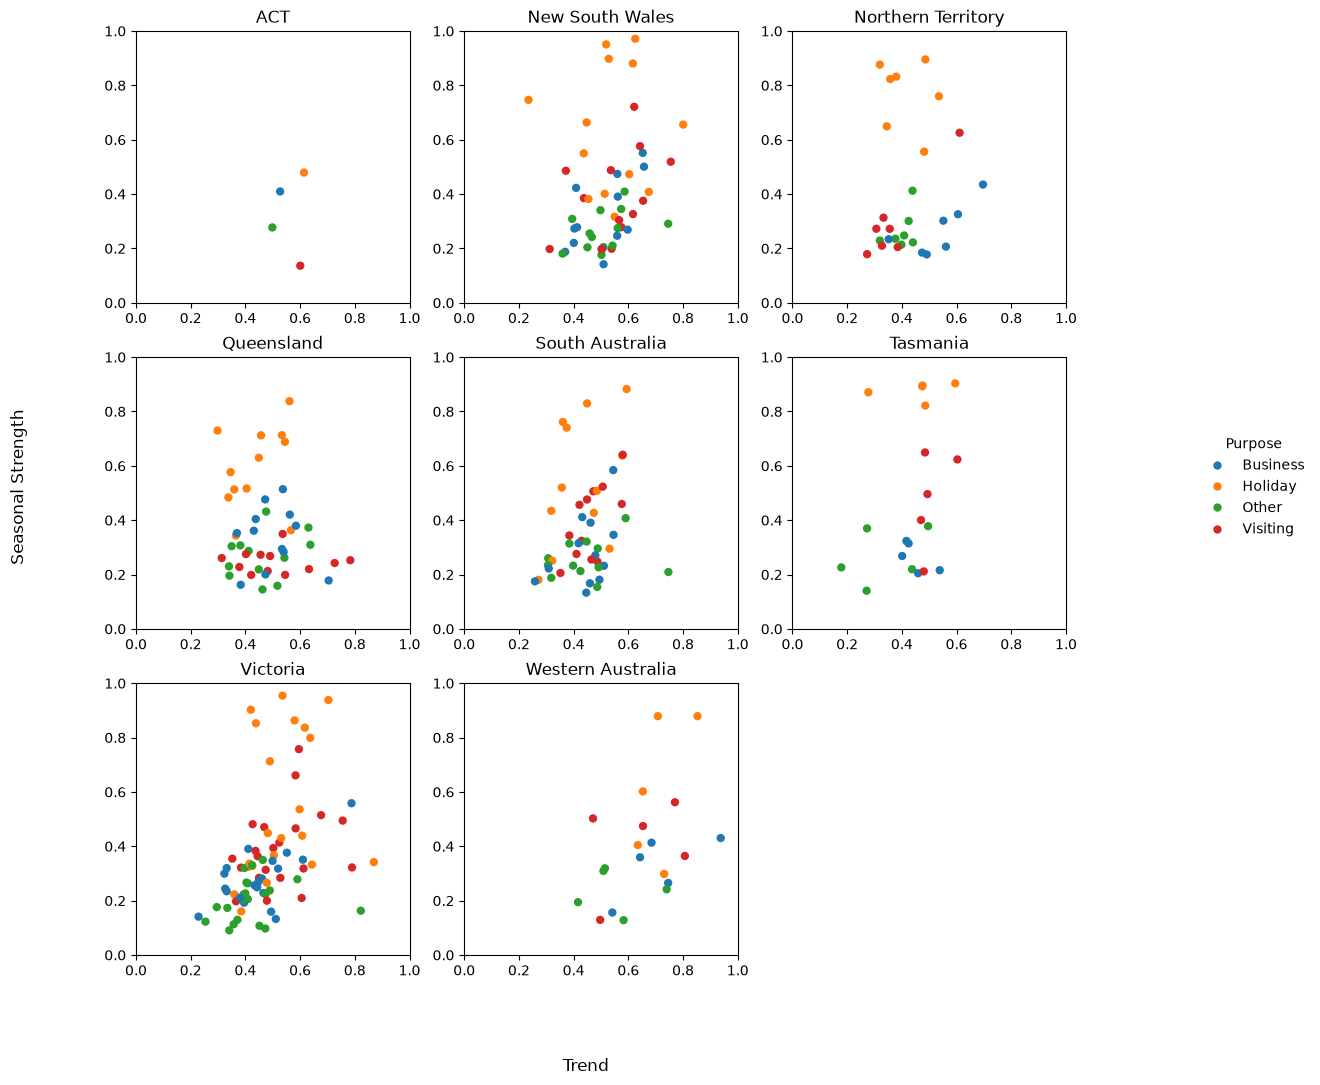

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

df = (stl_feat["unique_id"].str.split("-", expand=True).rename(columns={0: "region", 1: "state", 2: "purpose"}).join(stl_feat))
fig, axs = plt.subplots(3, 3, figsize=(12, 12))
axs = axs.flatten()

for ax, (state, state_df) in zip(axs, df.groupby('state')):
    sns.scatterplot(x="trend", y="seasonal_strength",hue="purpose", edgecolor="none", data=state_df, ax=ax)
    ax.get_legend().remove()
    ax.set(title=state, xlabel="", ylabel="", xlim=(0, 1), ylim=(0, 1))

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels,title="Purpose", loc="center left", frameon=False,bbox_to_anchor=(1.01, .5), borderaxespad=0)
fig.supxlabel('Trend')
fig.supylabel('Seasonal Strength')

for ax in axs:
    if not ax.lines:
        ax.set_visible(False)

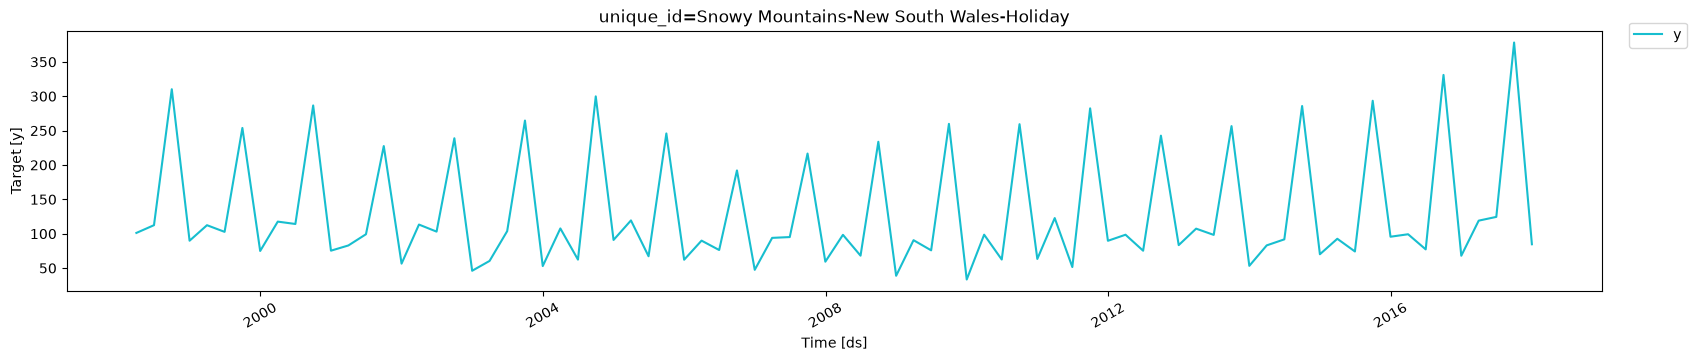

In [22]:
from utilsforecast.plotting import plot_series

row = stl_feat.loc[lambda x: x["seasonal_strength"].idxmax()]

plot_series(aus_tourism, ids=[row["unique_id"]])